In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightgbm as lgb

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings("ignore")


In [7]:
# Load feature-engineered dataset
df = pd.read_csv("bike_sharing_transformed_refined.csv")

print("Original shape:", df.shape)

# Drop NaNs caused by lag & rolling features
df = df.dropna().reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()


Original shape: (17379, 30)
Cleaned shape: (17211, 30)


,season,yr,holiday,workingday,weathersit,temp_actual,atemp_actual,humidity_actual,windspeed_actual,weather_comfort_index,...,demand_lag_168h,demand_rolling_24h,demand_rolling_72h,temp_rolling_72h,humidity_rolling_72h,weather_comfort_rolling_72h,workingday_rushhour,season_comfort,temp_humidity_interact,cnt
0,1,0,0,0,2,6.56,9.09,74,7.0015,0.387767,...,16.0,63.208333,66.277778,8.450556,49.027778,0.489934,0,0.387767,4.8544,9
1,1,0,0,0,3,6.56,9.09,93,7.0015,0.297433,...,40.0,60.083333,66.361111,8.427778,49.666667,0.487201,0,0.297433,6.1008,15
2,1,0,0,0,3,6.56,9.09,93,7.0015,0.297433,...,32.0,51.958333,66.111111,8.416389,50.361111,0.484329,0,0.297433,6.1008,20
3,1,0,0,0,2,7.38,9.85,80,11.0014,0.365827,...,13.0,47.208333,65.166667,8.405000,50.916667,0.482461,0,0.365827,5.9040,61
4,1,0,0,0,2,8.20,9.09,69,26.0027,0.362047,...,1.0,47.125000,63.305556,8.393611,51.361111,0.480388,0,0.362047,5.6580,62


In [8]:
X_hourly = df.drop(columns=["cnt"])
y_hourly = df["cnt"]

print("Hourly features:", X_hourly.shape)


Hourly features: (17211, 29)


In [9]:
split_idx = int(0.8 * len(df))

X_train_h = X_hourly.iloc[:split_idx]
X_test_h  = X_hourly.iloc[split_idx:]

y_train_h = y_hourly.iloc[:split_idx]
y_test_h  = y_hourly.iloc[split_idx:]


In [10]:
hourly_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

hourly_model.fit(X_train_h, y_train_h)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3064
[LightGBM] [Info] Number of data points in the train set: 13768, number of used features: 29
[LightGBM] [Info] Start training from score 176.516124
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,10
,learning_rate,0.05
,n_estimators,1500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
y_pred_h = hourly_model.predict(X_test_h)

r2_h  = r2_score(y_test_h, y_pred_h)
mae_h = mean_absolute_error(y_test_h, y_pred_h)
# compute RMSE via sqrt of MSE for compatibility with older sklearn versions
rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))

print(f"Hourly Model → R²: {r2_h:.4f}, MAE: {mae_h:.2f}, RMSE: {rmse_h:.2f}")


Hourly Model → R²: 0.9155, MAE: 39.83, RMSE: 63.90


In [12]:
# Create day index (24 hours = 1 day)
df["day_idx"] = np.arange(len(df)) // 24

agg_dict = {
    "cnt": "sum",
    "temp_actual": "mean",
    "humidity_actual": "mean",
    "windspeed_actual": "mean",
    "weather_comfort_index": "mean",
    "season": "first",
    "yr": "first",
    "holiday": "first",
    "workingday": "first",
    "weathersit": "max",
    "month_sin": "first",
    "day_sin": "first"
}

df_daily = df.groupby("day_idx").agg(agg_dict).reset_index(drop=True)

# Lag & rolling features (critical for 90%+ accuracy)
df_daily["cnt_lag1"] = df_daily["cnt"].shift(1)
df_daily["cnt_lag7"] = df_daily["cnt"].shift(7)
df_daily["rolling_temp_3d"] = df_daily["temp_actual"].rolling(3).mean()

# Strong demand memory features
df_daily["cnt_lag2"]  = df_daily["cnt"].shift(2)
df_daily["cnt_lag3"]  = df_daily["cnt"].shift(3)
df_daily["cnt_lag14"] = df_daily["cnt"].shift(14)
df_daily["cnt_lag30"] = df_daily["cnt"].shift(30)

# Rolling demand trends
df_daily["rolling_cnt_3"]  = df_daily["cnt"].rolling(3).mean()
df_daily["rolling_cnt_7"]  = df_daily["cnt"].rolling(7).mean()
df_daily["rolling_cnt_14"] = df_daily["cnt"].rolling(14).mean()

df_daily = df_daily.dropna().reset_index(drop=True)

print("Daily dataset shape:", df_daily.shape)


Daily dataset shape: (688, 22)


In [13]:
X_daily = df_daily.drop(columns=["cnt"])
y_daily = df_daily["cnt"]


In [14]:
split_idx_d = int(0.8 * len(df_daily))

X_train_d = X_daily.iloc[:split_idx_d]
X_test_d  = X_daily.iloc[split_idx_d:]

y_train_d = y_daily.iloc[:split_idx_d]
y_test_d  = y_daily.iloc[split_idx_d:]


In [15]:
daily_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=32,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

daily_model.fit(X_train_d, y_train_d)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2606
[LightGBM] [Info] Number of data points in the train set: 550, number of used features: 20
[LightGBM] [Info] Start training from score 4417.105455
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,32
,max_depth,6
,learning_rate,0.01
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
y_pred_d = daily_model.predict(X_test_d)

r2_d  = r2_score(y_test_d, y_pred_d)
mae_d = mean_absolute_error(y_test_d, y_pred_d)
# compute RMSE via sqrt of MSE for compatibility with older sklearn versions
rmse_d = np.sqrt(mean_squared_error(y_test_d, y_pred_d))

print(f"Daily Model → R²: {r2_d:.4f}, MAE: {mae_d:.2f}, RMSE: {rmse_d:.2f}")


Daily Model → R²: 0.8731, MAE: 526.95, RMSE: 672.16


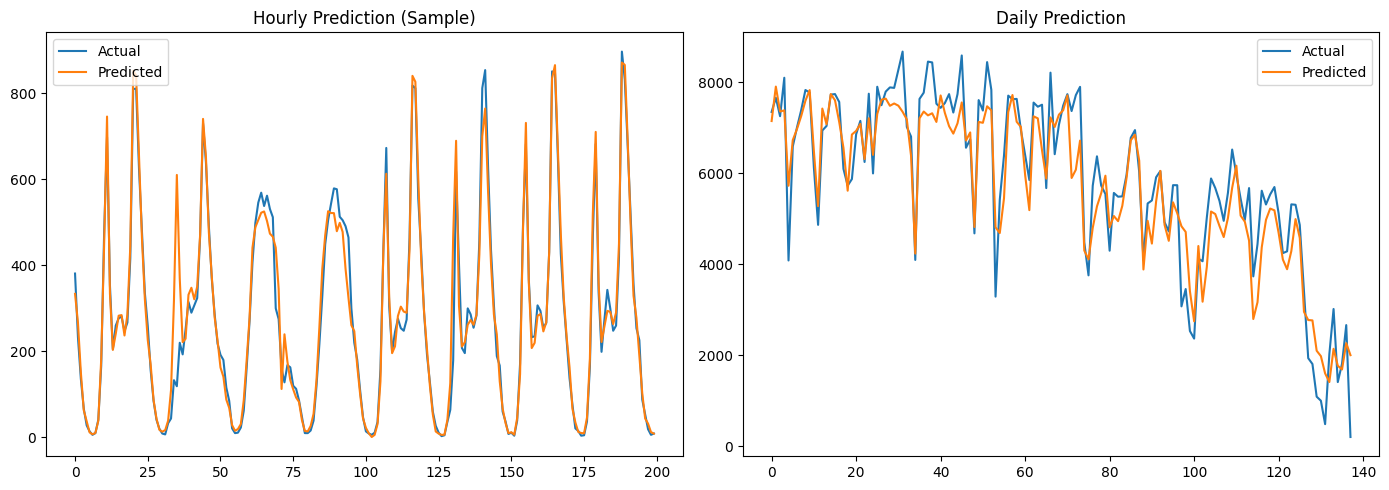

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test_h.values[:200], label="Actual")
plt.plot(y_pred_h[:200], label="Predicted")
plt.title("Hourly Prediction (Sample)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_test_d.values, label="Actual")
plt.plot(y_pred_d, label="Predicted")
plt.title("Daily Prediction")
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
joblib.dump(hourly_model, "bike_model_hourly.pkl")
joblib.dump(daily_model, "bike_model_daily.pkl")

print("Models saved successfully for Flask integration.")


Models saved successfully for Flask integration.


In [ ]:
import pickle

# Save feature names for Flask
pickle.dump(X_train_h.columns.tolist(), open("hourly_features.pkl", "wb"))
pickle.dump(X_train_d.columns.tolist(), open("daily_features.pkl", "wb"))

print("Feature pickle files created")


Feature pickle files created
